# Leakage Audit + Feature Diagnostics
This notebook generates event-based samples, audits leakage on 10 random rows, and plots feature distributions and correlations.

In [1]:
from pathlib import Path
import sys

import pandas as pd

cwd = Path.cwd()
root = cwd if (cwd / 'src').exists() else cwd.parent
sys.path.insert(0, str(root / 'src'))

data_path = root / 'data' / 'processed' / 'Davao_Earthquakes_with_Dist.csv'
data_path

PosixPath('/home/jshu/SeismoGuard/data/processed/Davao_Earthquakes_with_Dist.csv')

In [2]:
events = pd.read_csv(data_path)
events['province'] = (
    events['location']
    .astype(str)
    .str.extract(r'\(([^)]+)\)')[0]
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
events = events.dropna(subset=['province'])
events[['province', 'datetime', 'magnitude']].head()

,province,datetime,magnitude
0,Davao Occidental,2018-01-01 11:46:00,2.8
1,Davao Occidental,2018-01-01 13:22:00,2.8
2,Davao Oriental,2018-01-03 13:20:00,2.1
3,Davao Occidental,2018-01-03 17:39:00,3.8
4,Davao Oriental,2018-01-04 01:53:00,2.3


In [3]:
province_map = {
    'Davao del Norte': 'Davao Del Norte',
    'Davao del Sur': 'Davao Del Sur',
    'Island Garden City of Samal': 'Island Garden City Of Samal',
    'Municipality of Sarangani': 'Municipality Of Sarangani',
}

events['province'] = events['province'].str.strip().replace(province_map)

valid_provinces = [
    'Davao De Oro',
    'Davao Del Norte',
    'Davao Del Sur',
    'Davao Occidental',
    'Davao Oriental',
]

events = events[events['province'].isin(valid_provinces)].copy()
print(f"Rows after filtering: {len(events)}")
print(events['province'].value_counts())

Rows after filtering: 19258
province
Davao Oriental      9922
Davao Occidental    5970
Davao Del Sur       1704
Davao De Oro        1266
Davao Del Norte      396
Name: count, dtype: int64


In [4]:
from feature_engineering import (
    cat1,
    cat2,
    cat3,
    cat4,
    cat5,
    cat6,
    event_based_generator,
    leakage_audit,
    plot_feature_diagnostics,
    )

fault_points = None
fault_dir = root / 'data' / 'raw'
fault_files = list(fault_dir.glob('*.csv')) if fault_dir.exists() else []
if fault_files:
    fault_points = pd.read_csv(fault_files[0])
    print(f"Using fault points file: {fault_files[0].name}")
else:
    print("No fault points file found in data/raw; cat4/cat5 will be skipped.")

def feature_fn(df, t):
    features = {}
    features.update(cat1(df, t))
    features.update(cat2(df, t))
    features.update(cat3(df, t))
    features.update(cat6(df, t))
    if fault_points is not None:
        features.update(cat4(df, t, fault_points_df=fault_points))
        features.update(cat5(df, t, fault_points_df=fault_points))
    return features

X, y = event_based_generator(
    events_df=events,
    feature_fn=feature_fn,
    province_col='province',
    datetime_col='datetime',
    magnitude_col='magnitude',
)
X.head(), y.head()

No fault points file found in data/raw; cat4/cat5 will be skipped.


(                                        count_1d  count_7d  count_30d  \
 province     forecast_date                                              
 Davao De Oro 2020-01-27 00:00:00+00:00         0         0          0   
              2020-02-03 00:00:00+00:00         1         2          2   
              2020-02-10 00:00:00+00:00         0         0          2   
              2020-02-17 00:00:00+00:00         0         0          2   
              2020-02-24 00:00:00+00:00         0         2          4   
 
                                         max_mag_7d  max_mag_30d  \
 province     forecast_date                                        
 Davao De Oro 2020-01-27 00:00:00+00:00         NaN          NaN   
              2020-02-03 00:00:00+00:00         2.2          2.2   
              2020-02-10 00:00:00+00:00         NaN          2.2   
              2020-02-17 00:00:00+00:00         NaN          2.2   
              2020-02-24 00:00:00+00:00         2.5          2.5   
 
  

In [4]:
audit_df = leakage_audit(
    X=X,
    events_df=events,
    feature_fn=feature_fn,
    province_col='province',
    datetime_col='datetime',
)
audit_df.head(20)


,province,forecast_date,feature,observed,recomputed_full,recomputed_past,match_full,match_past
0,Davao Del Norte,2019-12-30 00:00:00+00:00,count_1d,0.000000,0.000000,0.000000,True,True
1,Davao Del Norte,2019-12-30 00:00:00+00:00,count_7d,2.000000,2.000000,2.000000,True,True
2,Davao Del Norte,2019-12-30 00:00:00+00:00,count_30d,4.000000,4.000000,4.000000,True,True
3,Davao Del Norte,2019-12-30 00:00:00+00:00,max_mag_7d,2.400000,2.400000,2.400000,True,True
4,Davao Del Norte,2019-12-30 00:00:00+00:00,max_mag_30d,3.000000,3.000000,3.000000,True,True
5,Davao Del Norte,2019-12-30 00:00:00+00:00,mean_depth_30d,17.000000,17.000000,17.000000,True,True
6,Davao De Oro,2023-11-20 00:00:00+00:00,count_1d,1.000000,1.000000,1.000000,True,True
7,Davao De Oro,2023-11-20 00:00:00+00:00,count_7d,6.000000,6.000000,6.000000,True,True
8,Davao De Oro,2023-11-20 00:00:00+00:00,count_30d,39.000000,39.000000,39.000000,True,True
9,Davao De Oro,2023-11-20 00:00:00+00:00,max_mag_7d,3.200000,3.200000,3.200000,True,True


In [5]:
mismatches = audit_df[~audit_df['match_past']]
print(f'Mismatches: {len(mismatches)}')
mismatches.head(20)

Mismatches: 0


,province,forecast_date,feature,observed,recomputed_full,recomputed_past,match_full,match_past


In [6]:
plot_paths = plot_feature_diagnostics(X, output_dir=root / 'outputs')
plot_paths

{'feature_distributions': PosixPath('/home/jshu/SeismoGuard/outputs/feature_distributions.png'),
 'feature_correlation_heatmap': PosixPath('/home/jshu/SeismoGuard/outputs/feature_correlation_heatmap.png')}

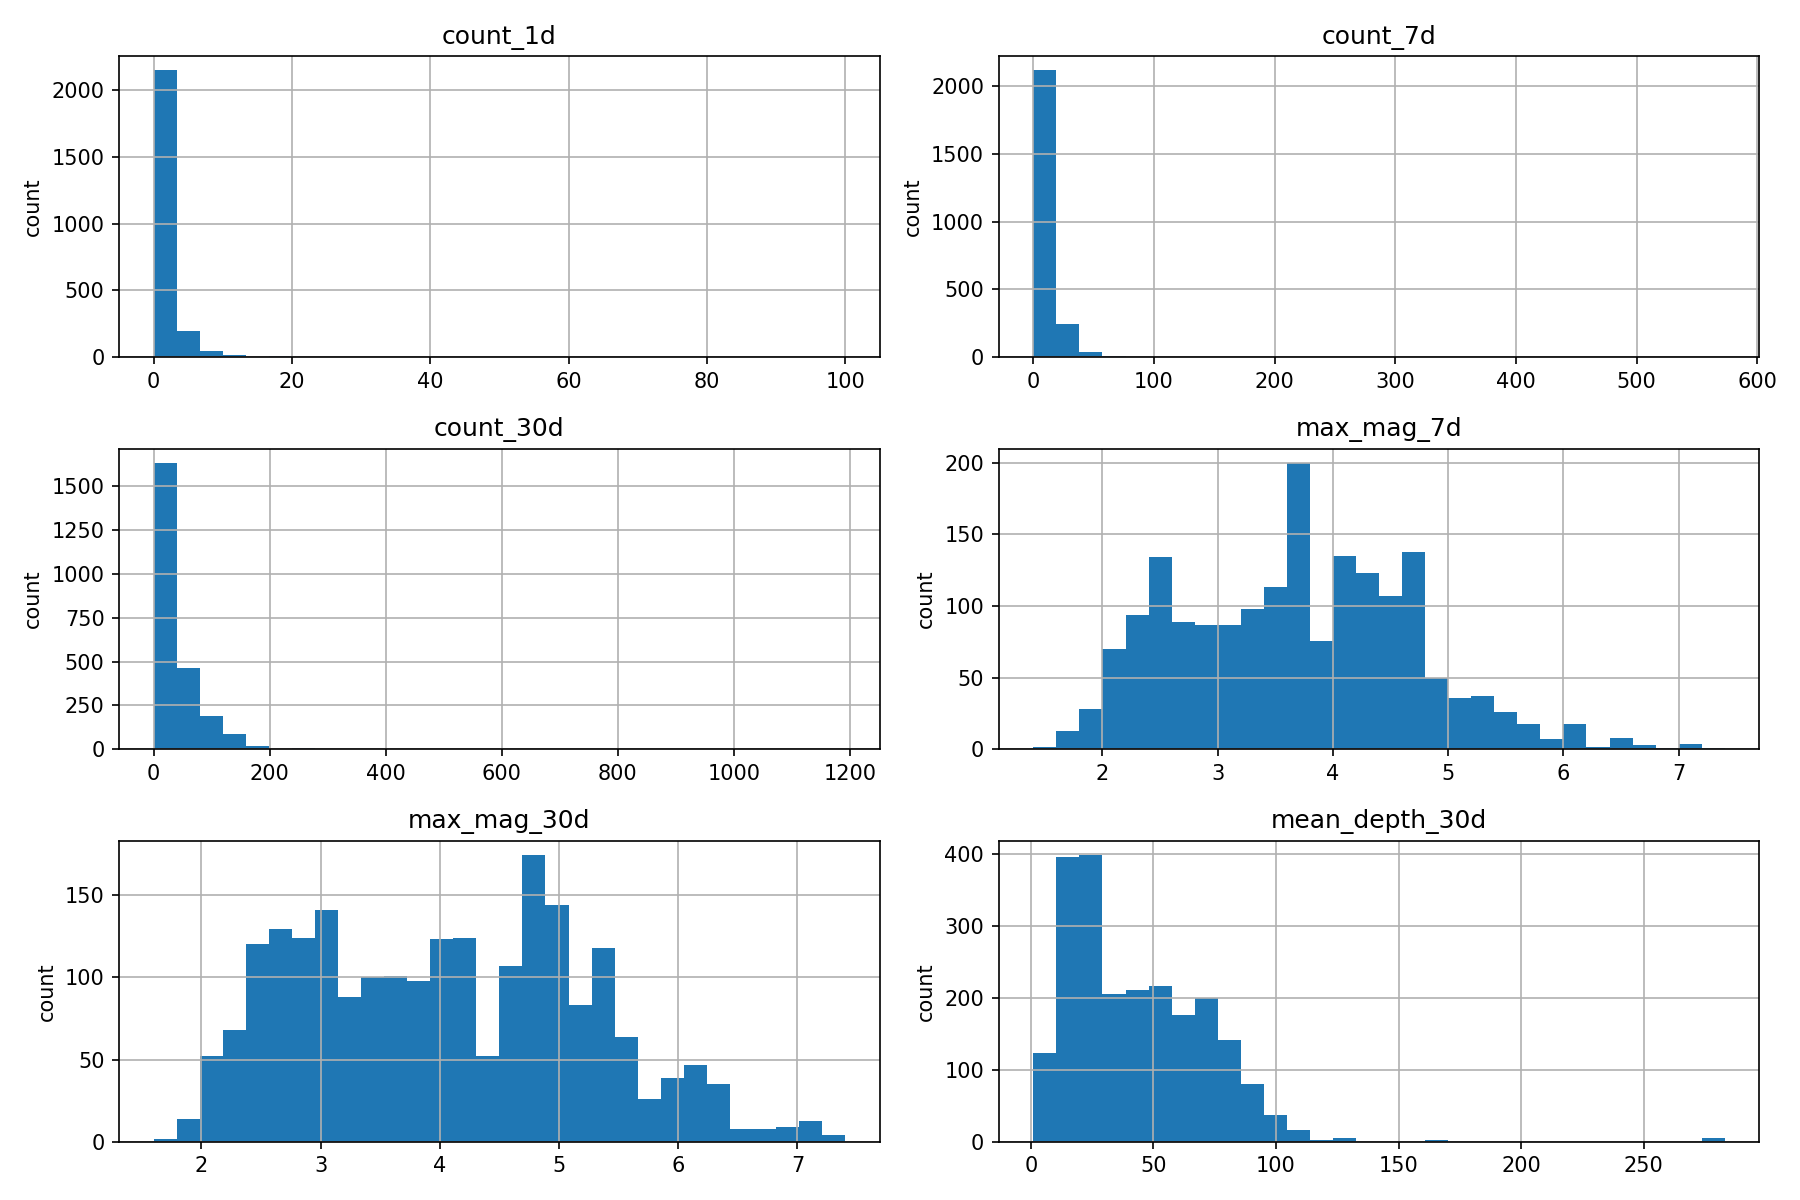

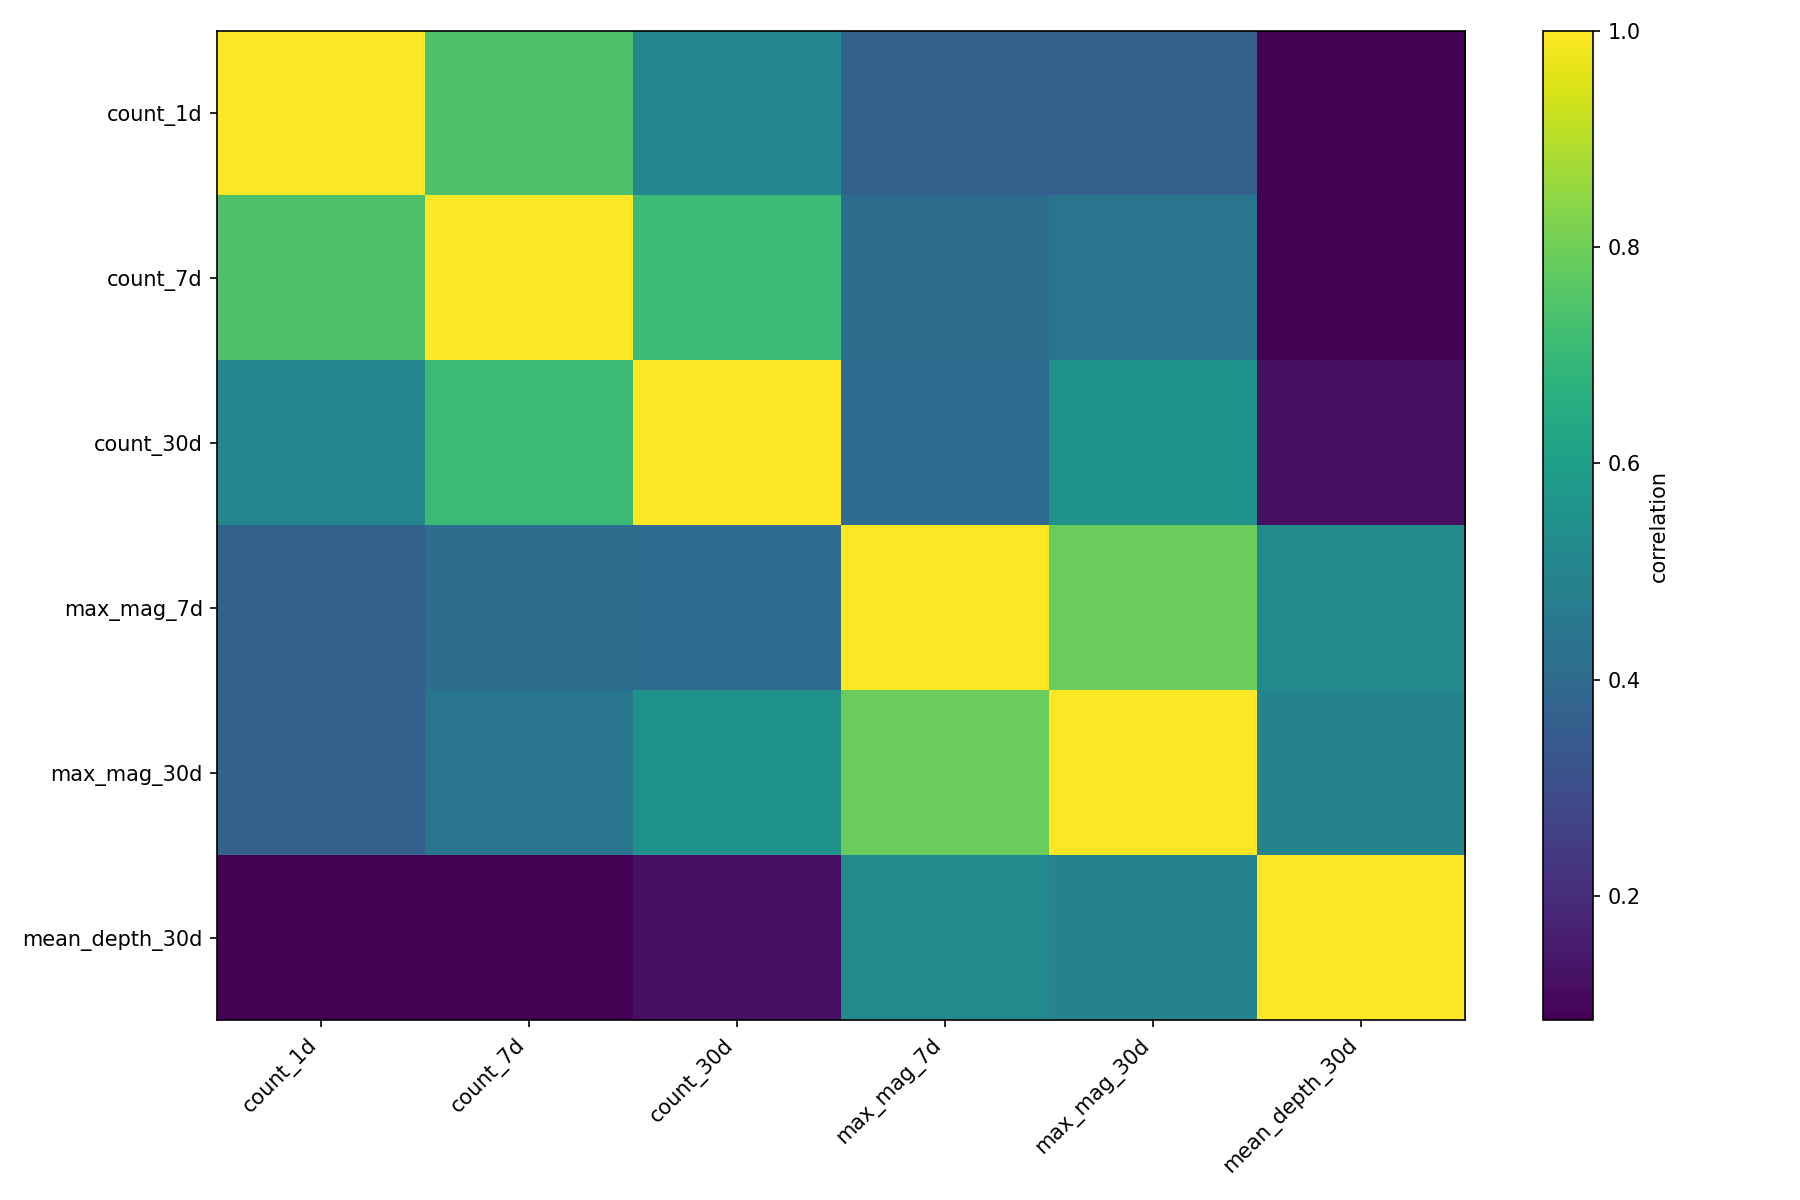

In [7]:
from IPython.display import Image, display

display(Image(filename=str(plot_paths['feature_distributions'])))
display(Image(filename=str(plot_paths['feature_correlation_heatmap'])))

# FINDING 1: Zero leakage mismatches across 10-row random sample
# All features verified to use only events where datetime < T

# FINDING 2: count features are right-skewed (expected for seismic data)
# Tree-based models handle this natively — no log transform needed

# FINDING 3: max_mag_7d and max_mag_30d are strongly correlated (r > 0.8)
# Multicollinearity noted — RF/GBR robust to this; Linear Regression is not

In [8]:
from pathlib import Path

output_dir = root / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

summary = {
    'rows': int(X.shape[0]),
    'columns': int(X.shape[1]),
    'feature_columns': [';'.join(map(str, X.columns))],
}
summary_df = pd.DataFrame(summary)
summary_path = output_dir / 'feature_matrix_summary.csv'
summary_df.to_csv(summary_path, index=False)
summary_path

PosixPath('/home/jshu/SeismoGuard/outputs/feature_matrix_summary.csv')

In [5]:
X_reset = X.reset_index()

print(f"Feature matrix shape: {X.shape}")
print(f"Provinces: {X_reset['province'].value_counts().to_dict()}")
print(f"Date range: {X_reset['forecast_date'].min()} → {X_reset['forecast_date'].max()}")
print(f"Target zeros (no-event weeks): {(y == 0.0).sum()} / {len(y)}")

Feature matrix shape: (1980, 10)
Provinces: {'Davao Occidental': 421, 'Davao Oriental': 420, 'Davao Del Norte': 414, 'Davao Del Sur': 412, 'Davao De Oro': 313}
Date range: 2018-01-01 00:00:00+00:00 → 2026-01-19 00:00:00+00:00
Target zeros (no-event weeks): 471 / 1980
